In [128]:
import numpy as np
print(np.__version__)

1.26.4


In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Customer Intelligence System
### Classification | Ensemble Learning (Random Forest, XGBoost) | Clustering (K-Means, DBSCAN)


**Objective :** Build an end-to-end customer intelligence pipeline using supervised and unsupervised ML techniques to achieve optimised predictive performance and actionable segmentation insights.

---

## Section 0 – Library Imports
Importing all required libraries for data analysis, visualisation, clustering, and classification.

In [132]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    silhouette_score, davies_bouldin_score, adjusted_rand_score
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import xgboost as xgb

print("=" * 65)
print("  CUSTOMER INTELLIGENCE SYSTEM – ALL MODULES LOADED SUCCESSFULLY")
print("=" * 65)

  CUSTOMER INTELLIGENCE SYSTEM – ALL MODULES LOADED SUCCESSFULLY


## Section 1 – Load & First Look at the Data
Loading the dataset (local CSV first; falls back to public GitHub mirror if not found). Then printing shape, dtypes, basic stats, missing values and duplicates.

In [134]:
# Try local file first, then fall back to public GitHub mirror
try:
    df_raw = pd.read_csv("Country-data.csv")
    print("   → Loaded from local 'Country-data.csv'")
except FileNotFoundError:
    url = ("https://raw.githubusercontent.com/pycaret/pycaret/"
           "main/datasets/country-data.csv")
    df_raw = pd.read_csv(url)
    print(f"   → Local file not found. Auto-loaded from:\n     {url}")

print(f"\n   Shape  : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

   → Loaded from local 'Country-data.csv'

   Shape  : 167 rows × 10 columns


In [135]:
print("── First 5 rows ──")
df_raw.head()

── First 5 rows ──


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [136]:
print("── Data Types & Non-Null Counts ──")
df_raw.info()

── Data Types & Non-Null Counts ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [137]:
print("── Basic Descriptive Statistics ──")
df_raw.describe().round(2)

── Basic Descriptive Statistics ──


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [138]:
print("── Missing Values per Column ──")
print(df_raw.isnull().sum())
print(f"\n── Duplicate Rows : {df_raw.duplicated().sum()} ──")

── Missing Values per Column ──
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

── Duplicate Rows : 0 ──


## Section 2 – Exploratory Data Analysis (EDA)
Visualising distributions, correlations, outliers, and key country rankings to understand the data before modelling.

In [140]:
numeric_cols = [c for c in df_raw.columns if c != "country"]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

Numeric features (9): ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


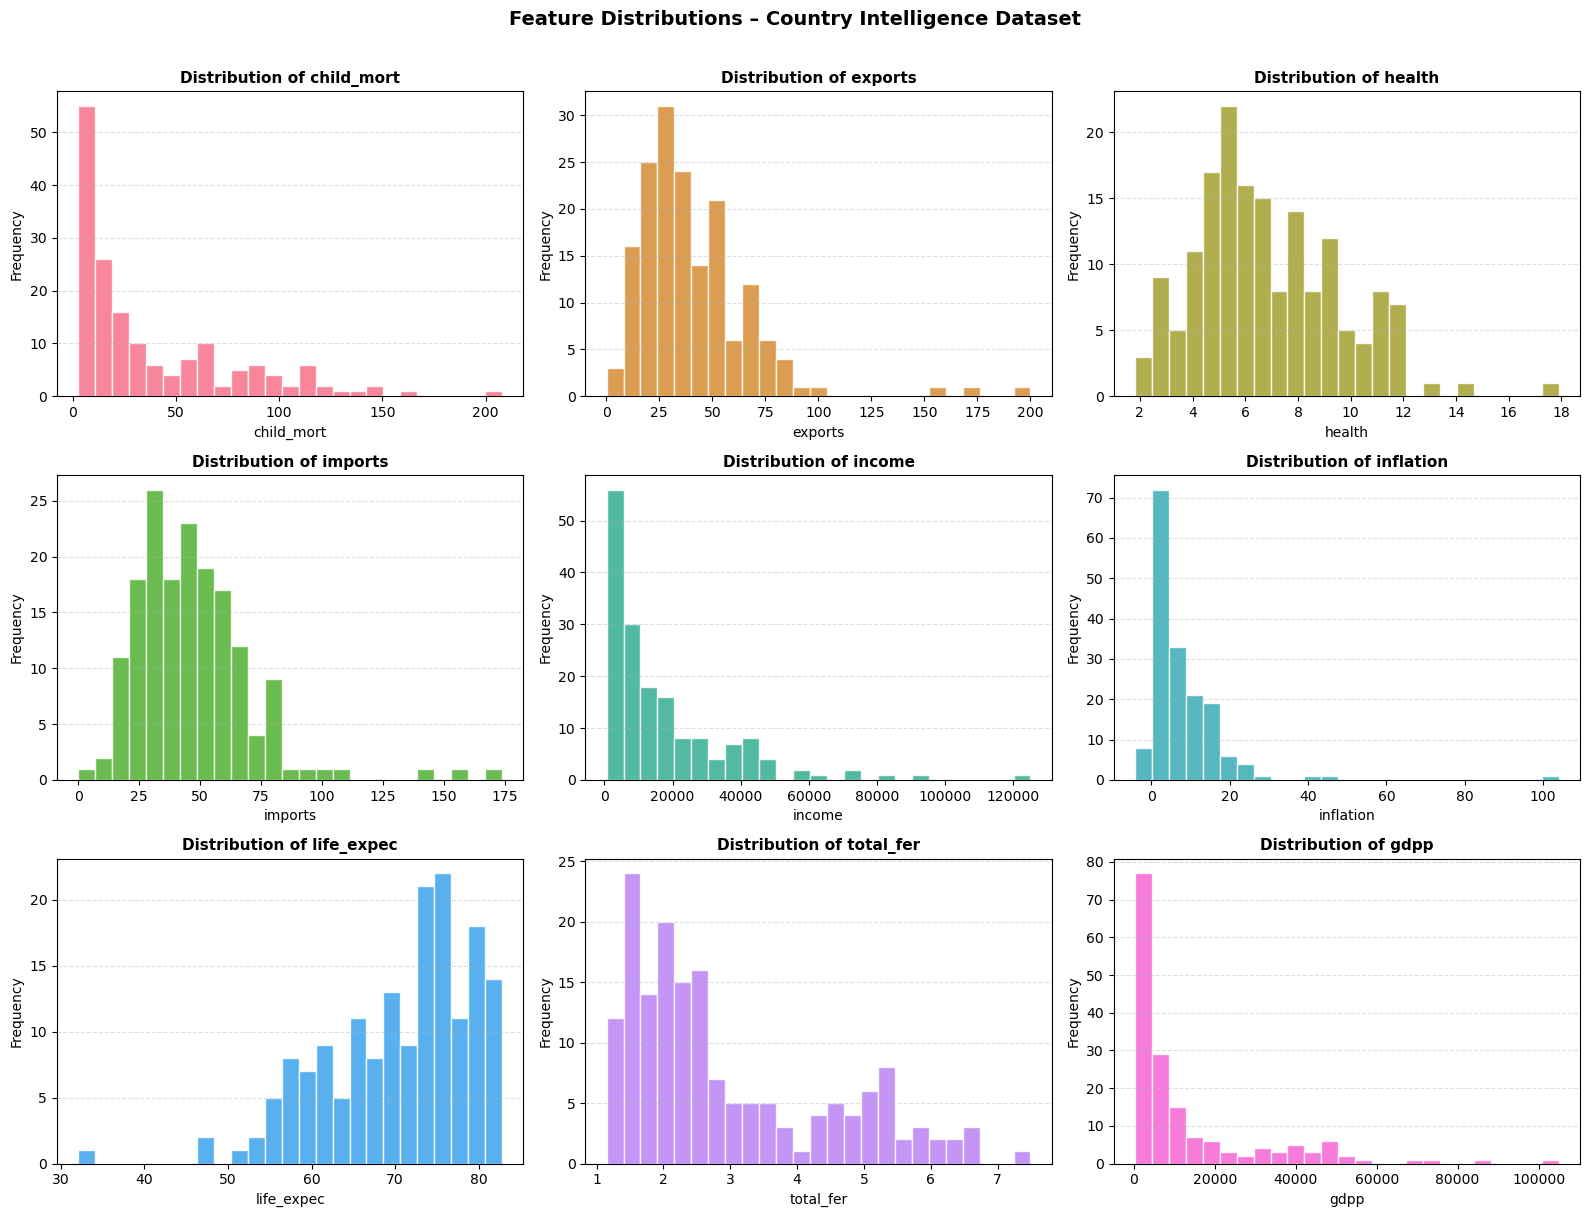

In [141]:
# ── 2.1  Feature Distribution Histograms ────────────────────────────────
colors = sns.color_palette("husl", len(numeric_cols))
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df_raw[col], bins=25, color=colors[idx],
                   edgecolor="white", alpha=0.85)
    axes[idx].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Frequency")
    axes[idx].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Feature Distributions – Country Intelligence Dataset",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("01_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

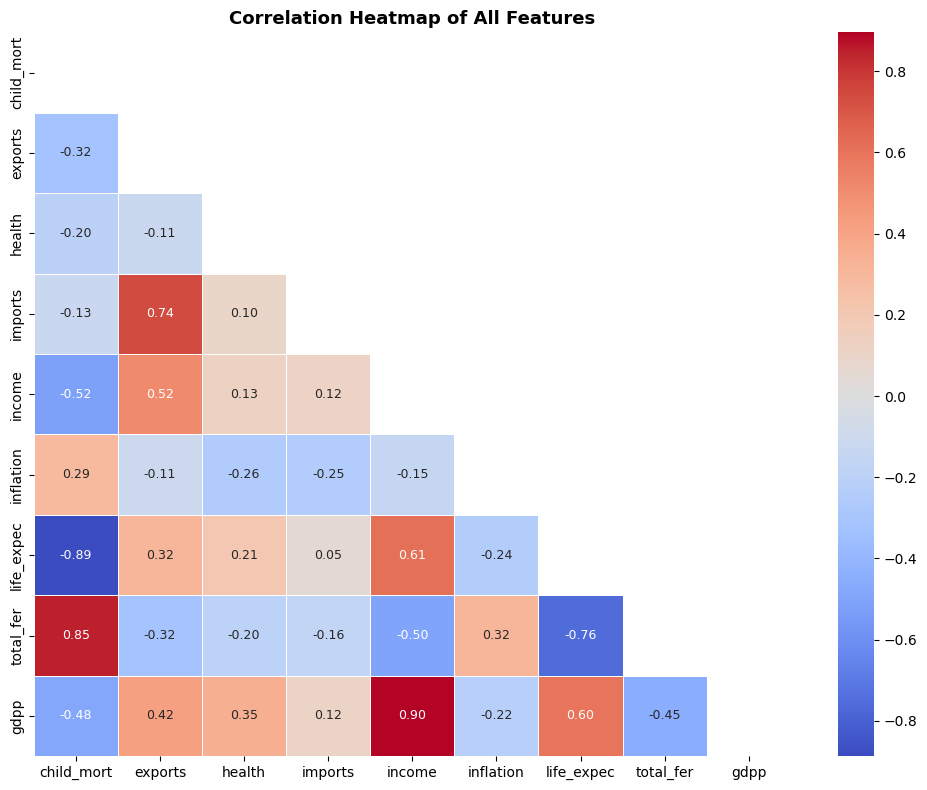

In [142]:
# ── 2.2  Correlation Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_raw[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, ax=ax,
            annot_kws={"size": 9})
ax.set_title("Correlation Heatmap of All Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

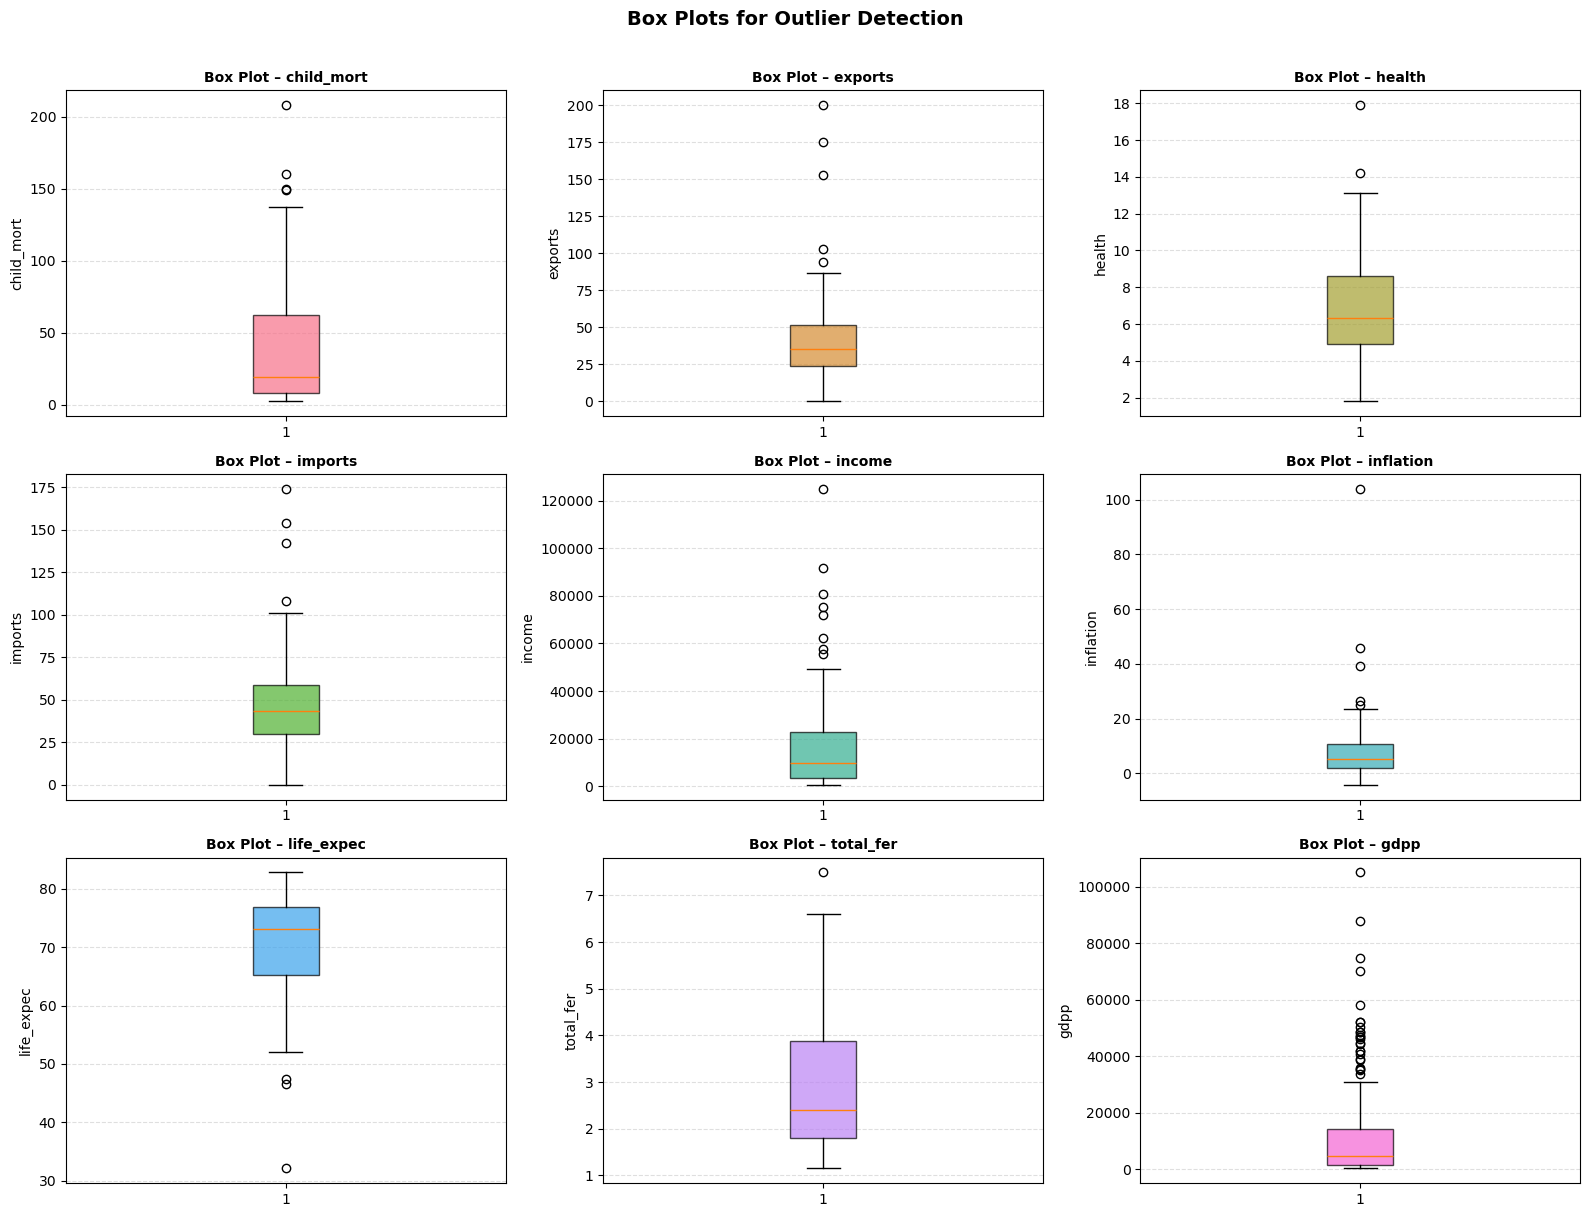

In [143]:
# ── 2.3  Box Plots for Outlier Detection ────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df_raw[col].dropna(), patch_artist=True,
                      boxprops=dict(facecolor=colors[idx], alpha=0.7))
    axes[idx].set_title(f"Box Plot – {col}", fontsize=10, fontweight="bold")
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Box Plots for Outlier Detection", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("03_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

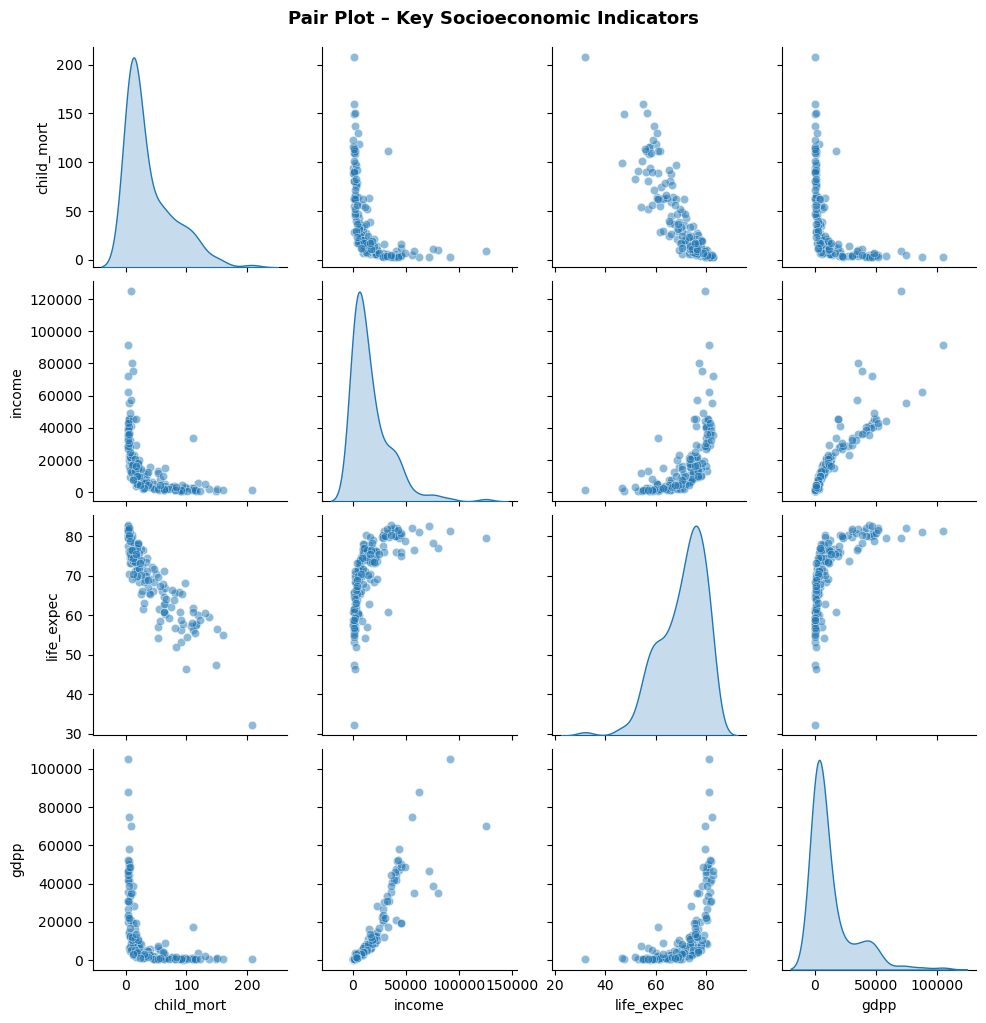

In [144]:
# ── 2.4  Pair Plot (Key Socioeconomic Indicators) ───────────────────────
subset_cols = ["child_mort", "income", "life_expec", "gdpp"]
pair_fig = sns.pairplot(df_raw[subset_cols].copy(),
                        diag_kind="kde", plot_kws={"alpha": 0.5})
pair_fig.fig.suptitle("Pair Plot – Key Socioeconomic Indicators",
                      y=1.02, fontsize=13, fontweight="bold")
plt.savefig("04_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

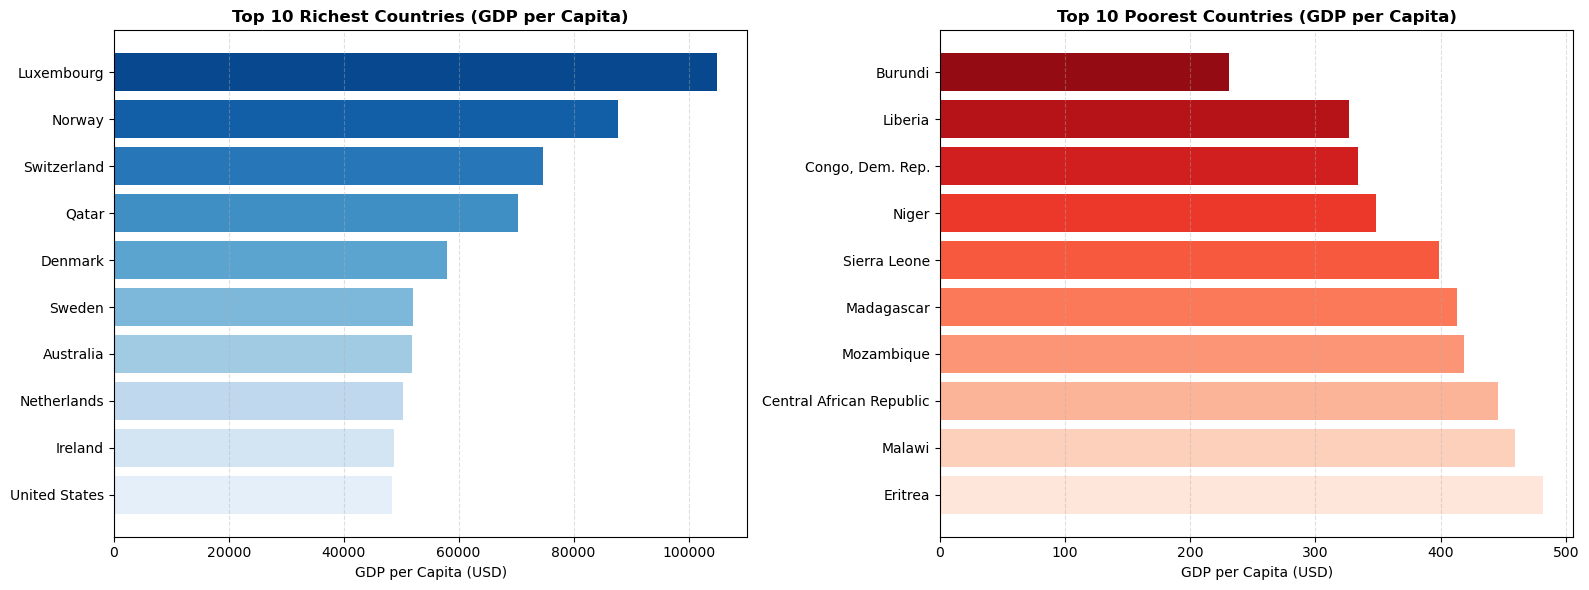

In [145]:
# ── 2.5  Top 10 Richest vs Poorest Countries ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top10_rich = df_raw.nlargest(10, "gdpp")
top10_poor = df_raw.nsmallest(10, "gdpp")

ax1.barh(top10_rich["country"], top10_rich["gdpp"],
         color=sns.color_palette("Blues_r", 10))
ax1.set_title("Top 10 Richest Countries (GDP per Capita)", fontsize=12, fontweight="bold")
ax1.set_xlabel("GDP per Capita (USD)")
ax1.invert_yaxis()
ax1.grid(axis="x", linestyle="--", alpha=0.4)

ax2.barh(top10_poor["country"], top10_poor["gdpp"],
         color=sns.color_palette("Reds_r", 10))
ax2.set_title("Top 10 Poorest Countries (GDP per Capita)", fontsize=12, fontweight="bold")
ax2.set_xlabel("GDP per Capita (USD)")
ax2.invert_yaxis()
ax2.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("05_rich_vs_poor.png", dpi=150, bbox_inches="tight")
plt.show()

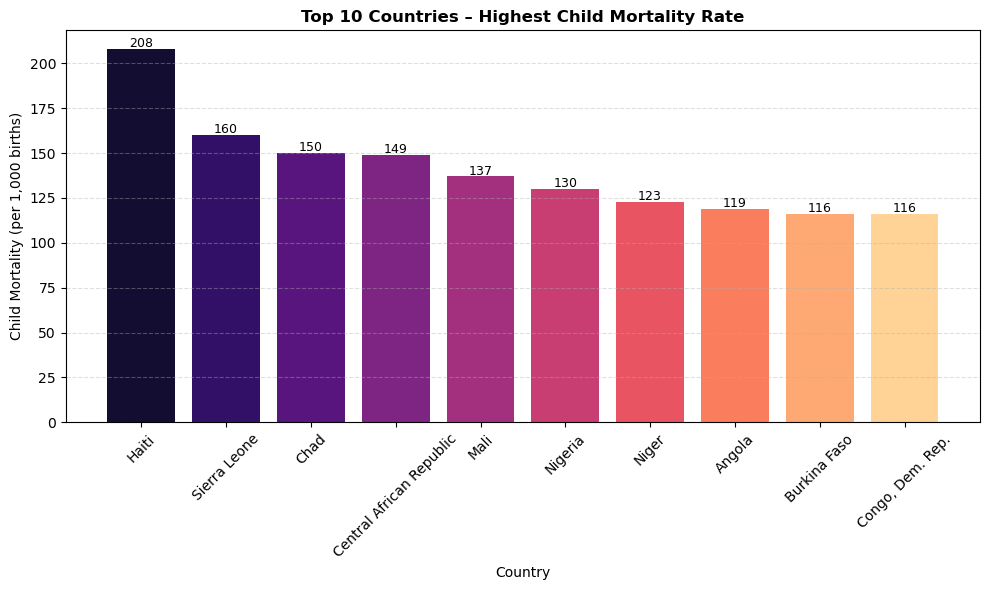

In [146]:
# ── 2.6  Top 10 Countries – Highest Child Mortality ─────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
top10_mort = df_raw.nlargest(10, "child_mort")
bars = ax.bar(top10_mort["country"], top10_mort["child_mort"],
              color=sns.color_palette("magma", 10))
ax.set_title("Top 10 Countries – Highest Child Mortality Rate",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Country")
ax.set_ylabel("Child Mortality (per 1,000 births)")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.4)
for bar_obj in bars:
    ax.text(bar_obj.get_x() + bar_obj.get_width() / 2,
            bar_obj.get_height() + 1,
            f"{bar_obj.get_height():.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("06_child_mortality_top10.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 3 – Data Preprocessing
- Handling missing values (median imputation)
- Standardising features with `StandardScaler`
- Engineering a **Development Status** target label using GDP, life expectancy and child mortality thresholds

In [148]:
country_names = df_raw["country"].values
X_num = df_raw[numeric_cols].copy()

# Handle missing values if any
if X_num.isnull().sum().sum() > 0:
    X_num.fillna(X_num.median(), inplace=True)
    print("   → Missing values imputed with column medians")
else:
    print("   → No missing values detected")

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
print("   → Features standardised  (mean ≈ 0, std ≈ 1)")
X_scaled_df.describe().round(3)

   → No missing values detected
   → Features standardised  (mean ≈ 0, std ≈ 1)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000,167.000,167.000,167.000,167.000,167.000,167.000,167.000,167.000
mean,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003
min,-0.887,-1.500,-1.828,-1.940,-0.860,-1.138,-4.337,-1.191,-0.697
25%,-0.747,-0.633,-0.692,-0.691,-0.717,-0.567,-0.593,-0.764,-0.637
50%,-0.472,-0.224,-0.181,-0.149,-0.374,-0.227,0.287,-0.356,-0.454
75%,0.593,0.375,0.652,0.491,0.294,0.282,0.704,0.618,0.059
max,4.221,5.814,4.047,5.266,5.612,9.130,1.381,3.009,5.037


In [149]:
# ── Rule-based Development Status label ─────────────────────────────────
def label_country(row):
    if row["gdpp"] >= 15000 and row["life_expec"] >= 75 and row["child_mort"] <= 20:
        return "Developed"
    elif row["gdpp"] <= 3000 or row["child_mort"] >= 60:
        return "Underdeveloped"
    else:
        return "Developing"

df_raw["dev_status"] = df_raw.apply(label_country, axis=1)
print("── Development Status Distribution ──")
print(df_raw["dev_status"].value_counts())

── Development Status Distribution ──
dev_status
Underdeveloped    68
Developing        60
Developed         39
Name: count, dtype: int64


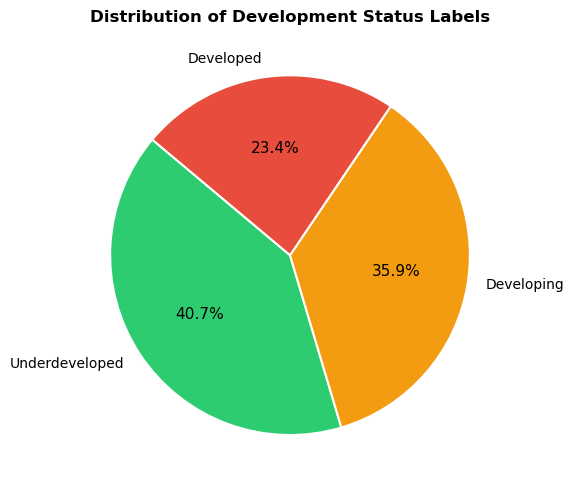

In [150]:
# Pie chart of label distribution
label_counts = df_raw["dev_status"].value_counts()
fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct="%1.1f%%",
    colors=["#2ecc71", "#f39c12", "#e74c3c"],
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for t in autotexts:
    t.set_fontsize(11)
ax.set_title("Distribution of Development Status Labels",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("07_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4 – Dimensionality Reduction with PCA
PCA helps us understand which features carry the most variance and allows 2-D visualisation of multi-dimensional country data.

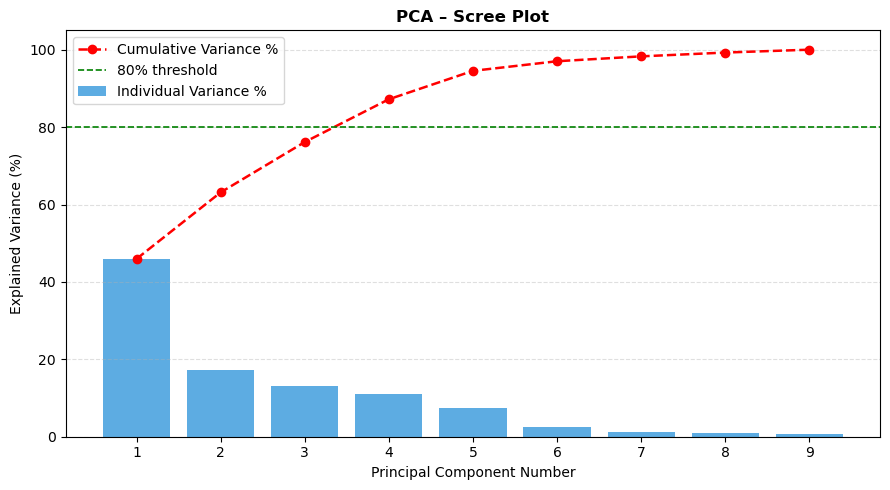

   → 4 components explain ≥ 80% of variance


In [152]:
# Full PCA to find explained variance per component
pca_full = PCA()
pca_full.fit(X_scaled)
explained_var  = pca_full.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)

# Scree plot
fig, ax = plt.subplots(figsize=(9, 5))
components = range(1, len(explained_var) + 1)
ax.bar(components, explained_var, color="#3498db", alpha=0.8,
       label="Individual Variance %")
ax.plot(components, cumulative_var, "ro--", linewidth=1.8,
        markersize=6, label="Cumulative Variance %")
ax.axhline(y=80, color="green", linestyle="--", linewidth=1.2,
           label="80% threshold")
ax.set_xlabel("Principal Component Number")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("PCA – Scree Plot", fontsize=12, fontweight="bold")
ax.set_xticks(list(components))
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("08_pca_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

n_comp = int(np.argmax(cumulative_var >= 80)) + 1
print(f"   → {n_comp} components explain ≥ 80% of variance")

Variance captured by PC1 + PC2 : 63.1%


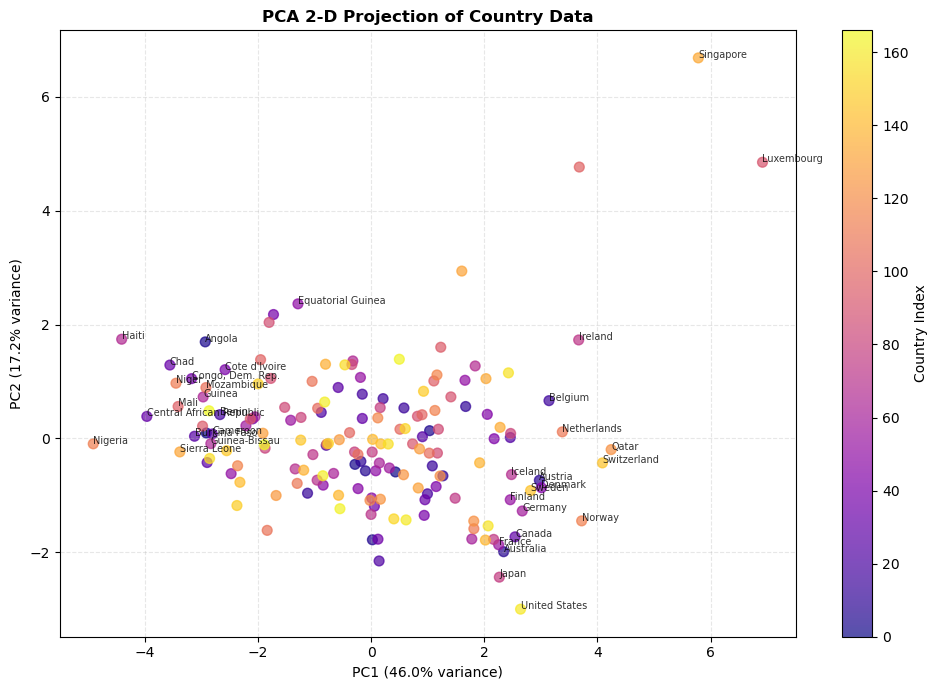

In [153]:
# 2-component PCA for 2-D visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance captured by PC1 + PC2 : {sum(pca.explained_variance_ratio_)*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7,
                     c=range(len(X_pca)), cmap="plasma", s=50)
for i, name in enumerate(country_names):
    if df_raw["gdpp"].iloc[i] >= 40000 or df_raw["child_mort"].iloc[i] >= 100:
        ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=7, alpha=0.8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA 2-D Projection of Country Data", fontsize=12, fontweight="bold")
ax.grid(linestyle="--", alpha=0.3)
plt.colorbar(scatter, ax=ax, label="Country Index")
plt.tight_layout()
plt.savefig("09_pca_2d_projection.png", dpi=150, bbox_inches="tight")
plt.show()

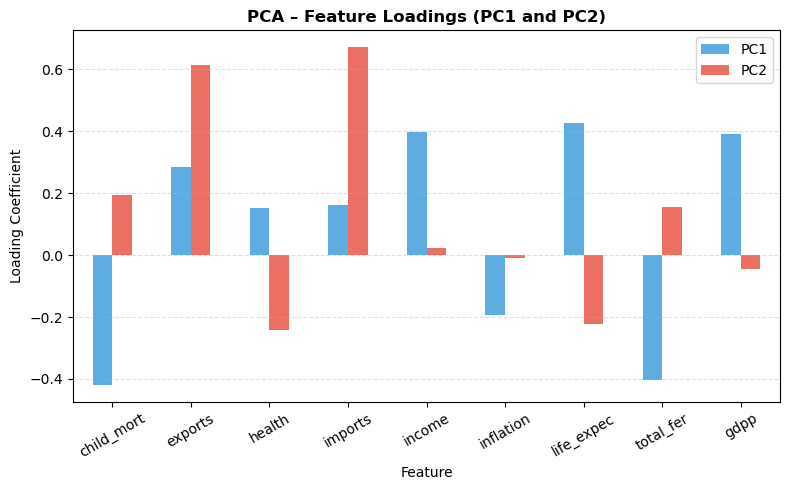


── Feature Loadings Table ──


,PC1,PC2
child_mort,-0.420,0.193
exports,0.284,0.613
health,0.151,-0.243
imports,0.161,0.672
income,0.398,0.023
inflation,-0.193,-0.008
life_expec,0.426,-0.223
total_fer,-0.404,0.155
gdpp,0.393,-0.046


In [154]:
# PCA Feature Loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=["PC1", "PC2"],
                        index=numeric_cols)
fig, ax = plt.subplots(figsize=(8, 5))
loadings.plot(kind="bar", ax=ax,
              color=["#3498db", "#e74c3c"], alpha=0.8)
ax.set_title("PCA – Feature Loadings (PC1 and PC2)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Feature"); ax.set_ylabel("Loading Coefficient")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", linestyle="--", alpha=0.4); ax.legend(loc="best")
plt.tight_layout()
plt.savefig("10_pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n── Feature Loadings Table ──")
loadings.round(3)

## Section 5 – K-Means Clustering
Using the **Elbow method** and **Silhouette score** to find the optimal number of clusters, then fitting K-Means and analysing cluster profiles.

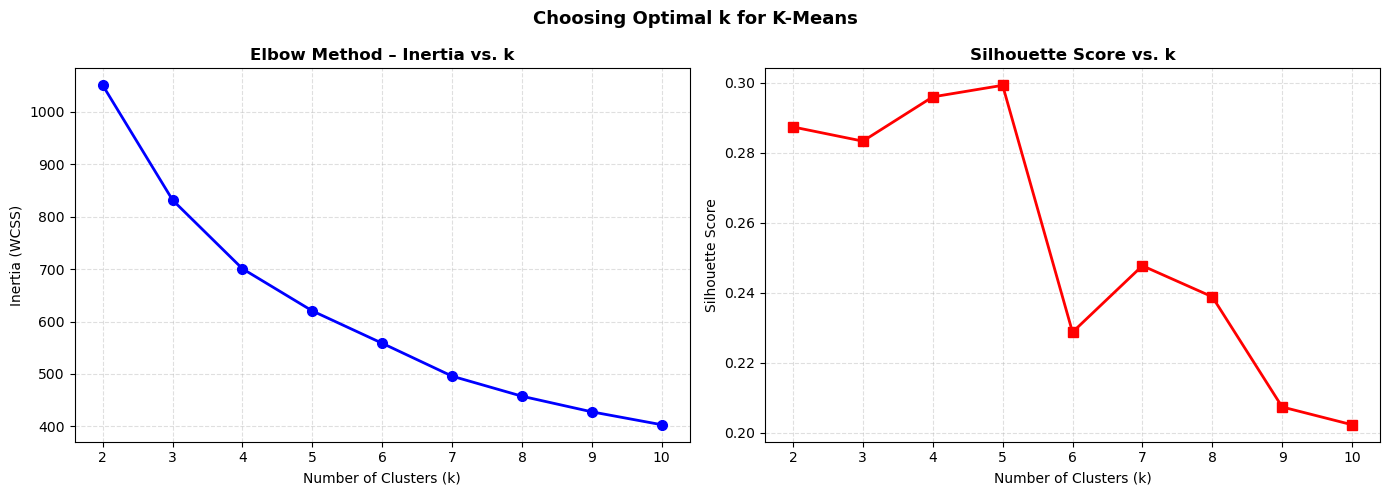

   → Best k by silhouette : 5  (score = 0.2993)


In [156]:
# Elbow + Silhouette across k = 2 … 10
inertias   = []
sil_scores = []
k_range    = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(k_range), inertias, "b-o", linewidth=2, markersize=7)
ax1.set_title("Elbow Method – Inertia vs. k", fontsize=12, fontweight="bold")
ax1.set_xlabel("Number of Clusters (k)"); ax1.set_ylabel("Inertia (WCSS)")
ax1.grid(linestyle="--", alpha=0.4)

ax2.plot(list(k_range), sil_scores, "r-s", linewidth=2, markersize=7)
ax2.set_title("Silhouette Score vs. k", fontsize=12, fontweight="bold")
ax2.set_xlabel("Number of Clusters (k)"); ax2.set_ylabel("Silhouette Score")
ax2.grid(linestyle="--", alpha=0.4)

plt.suptitle("Choosing Optimal k for K-Means", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("11_kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = list(k_range)[np.argmax(sil_scores)]
print(f"   → Best k by silhouette : {best_k}  (score = {max(sil_scores):.4f})")

In [157]:
# Fit final K-Means with best_k
kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df_raw["kmeans_cluster"] = kmeans_labels

print(f"K-Means Silhouette Score : {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"K-Means Davies-Bouldin   : {davies_bouldin_score(X_scaled, kmeans_labels):.4f}")

K-Means Silhouette Score : 0.2993
K-Means Davies-Bouldin   : 0.8718


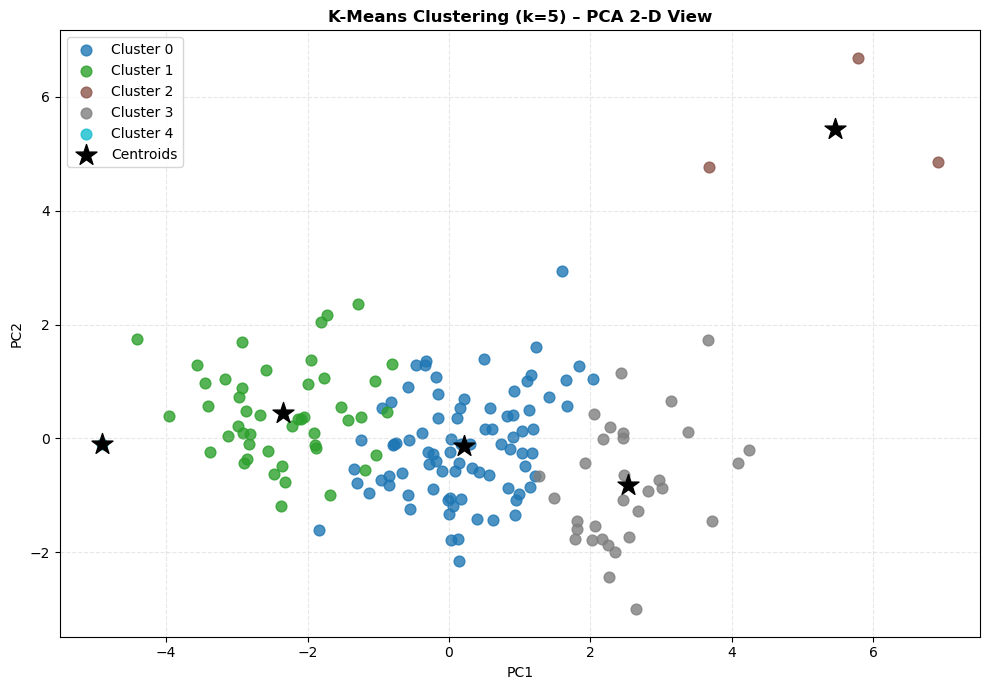

In [158]:
# Visualise clusters in PCA space
cmap_clusters = plt.cm.get_cmap("tab10", best_k)
fig, ax = plt.subplots(figsize=(10, 7))
for clust in range(best_k):
    mask = kmeans_labels == clust
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f"Cluster {clust}", s=60, alpha=0.8,
               color=cmap_clusters(clust))
centers_2d = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_2d[:, 0], centers_2d[:, 1],
           marker="*", s=250, c="black", zorder=5, label="Centroids")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"K-Means Clustering (k={best_k}) – PCA 2-D View",
             fontsize=12, fontweight="bold")
ax.legend(); ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("12_kmeans_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

── Cluster Profiles (Mean Values) ──
                child_mort  exports  health  imports    income  inflation  \
kmeans_cluster                                                              
0                    21.61    40.98    6.17    47.52  12801.07       7.62   
1                    90.79    29.66    6.46    43.68   3870.70       9.95   
2                     4.13   176.00    6.79   156.67  64033.33       2.47   
3                     5.18    46.12    9.09    40.58  44021.88       2.51   
4                   130.00    25.30    5.07    17.40   5150.00     104.00   

                life_expec  total_fer      gdpp  
kmeans_cluster                                   
0                    73.00       2.28   6581.81  
1                    59.21       4.97   1900.26  
2                    81.43       1.38  57566.67  
3                    80.08       1.79  42118.75  
4                    60.50       5.84   2330.00  


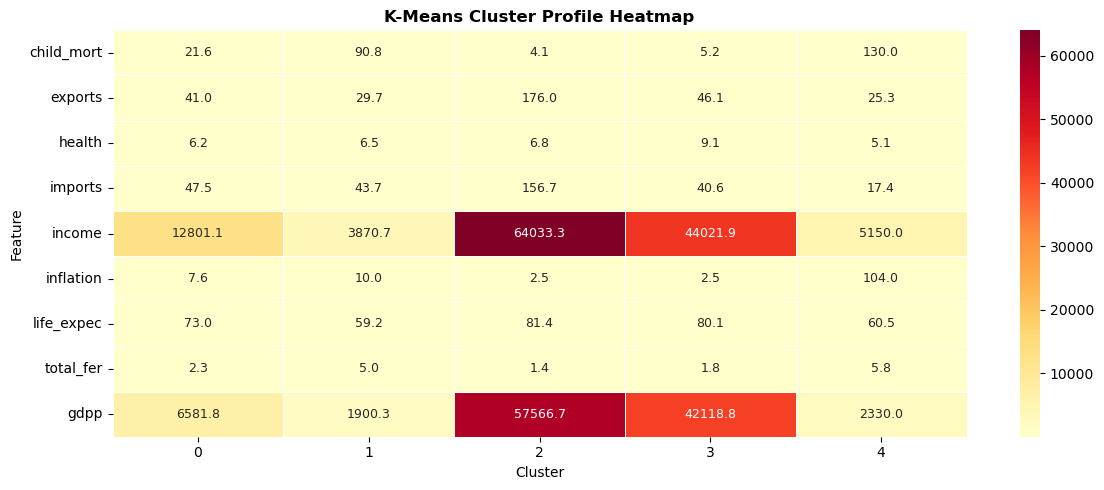

In [159]:
# Cluster Profile Heatmap
cluster_profiles = df_raw.groupby("kmeans_cluster")[numeric_cols].mean()
print("── Cluster Profiles (Mean Values) ──")
print(cluster_profiles.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt=".1f",
            cmap="YlOrRd", linewidths=0.4, ax=ax, annot_kws={"size": 9})
ax.set_title("K-Means Cluster Profile Heatmap", fontsize=12, fontweight="bold")
ax.set_xlabel("Cluster"); ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("13_kmeans_cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [160]:
# Countries per cluster
for c in range(best_k):
    countries_in = df_raw[df_raw["kmeans_cluster"] == c]["country"].values
    preview = ", ".join(countries_in[:12]) + (" ..." if len(countries_in) > 12 else "")
    print(f"\nCluster {c}  ({len(countries_in)} countries):\n  {preview}")


Cluster 0  (84 countries):
  Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahrain, Bangladesh, Barbados, Belarus, Belize, Bhutan ...

Cluster 1  (47 countries):
  Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep. ...

Cluster 2  (3 countries):
  Luxembourg, Malta, Singapore

Cluster 3  (32 countries):
  Australia, Austria, Bahamas, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany ...

Cluster 4  (1 countries):
  Nigeria


## Section 6 – DBSCAN Clustering
**Density-Based Spatial Clustering of Applications with Noise** — can detect arbitrarily shaped clusters and flag outlier countries as noise.

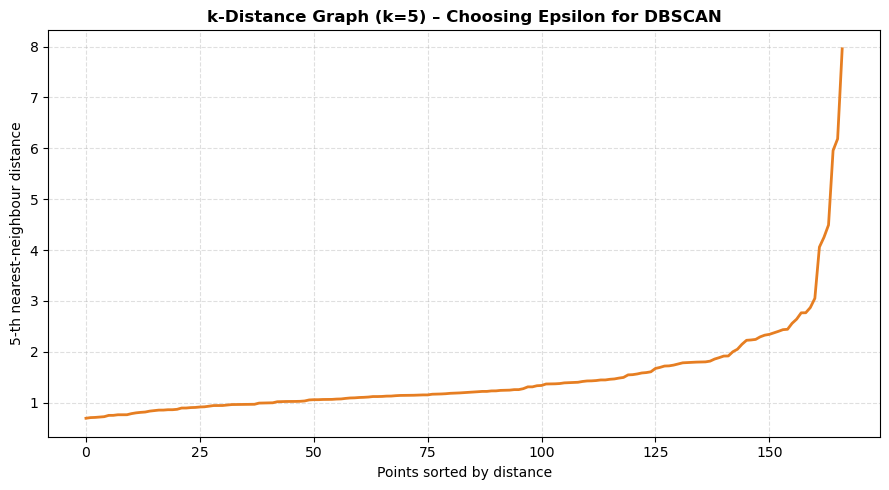

In [162]:
# k-distance graph to choose epsilon
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_dist, color="#e67e22", linewidth=2)
ax.set_title("k-Distance Graph (k=5) – Choosing Epsilon for DBSCAN",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel("5-th nearest-neighbour distance")
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("14_dbscan_kdistance.png", dpi=150, bbox_inches="tight")
plt.show()

In [163]:
# Parameter grid search for best (eps, min_samples)
dbscan_results = []
eps_candidates        = [1.5, 2.0, 2.5, 3.0]
min_samples_candidates = [3, 5]

for eps_val in eps_candidates:
    for ms in min_samples_candidates:
        db_temp   = DBSCAN(eps=eps_val, min_samples=ms)
        db_labels = db_temp.fit_predict(X_scaled)
        n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
        n_noise    = (db_labels == -1).sum()
        sil = silhouette_score(X_scaled, db_labels) if n_clusters >= 2 else -1
        dbscan_results.append({"eps": eps_val, "min_samples": ms,
                                "n_clusters": n_clusters, "n_noise": n_noise,
                                "silhouette": round(sil, 4)})

dbscan_df = pd.DataFrame(dbscan_results)
print("── DBSCAN Parameter Search ──")
dbscan_df

── DBSCAN Parameter Search ──


,eps,min_samples,n_clusters,n_noise,silhouette
0,1.5,3,2,25,0.154
1,1.5,5,1,30,-1.000
2,2.0,3,1,11,-1.000
3,2.0,5,1,15,-1.000
4,2.5,3,1,6,-1.000
5,2.5,5,1,6,-1.000
6,3.0,3,1,6,-1.000
7,3.0,5,1,6,-1.000


In [164]:
# Pick best combo with ≥2 clusters
best_dbscan = dbscan_df[dbscan_df["n_clusters"] >= 2].sort_values(
    "silhouette", ascending=False).iloc[0]
best_eps = best_dbscan["eps"]
best_ms  = int(best_dbscan["min_samples"])
n_db_clusters = int(best_dbscan["n_clusters"])

print(f"Best params   : eps={best_eps}, min_samples={best_ms}")
print(f"Clusters found: {n_db_clusters}")
print(f"Noise points  : {int(best_dbscan['n_noise'])}")
print(f"Silhouette    : {best_dbscan['silhouette']}")

dbscan       = DBSCAN(eps=best_eps, min_samples=best_ms)
dbscan_labels = dbscan.fit_predict(X_scaled)
df_raw["dbscan_cluster"] = dbscan_labels

Best params   : eps=1.5, min_samples=3
Clusters found: 2
Noise points  : 25
Silhouette    : 0.154


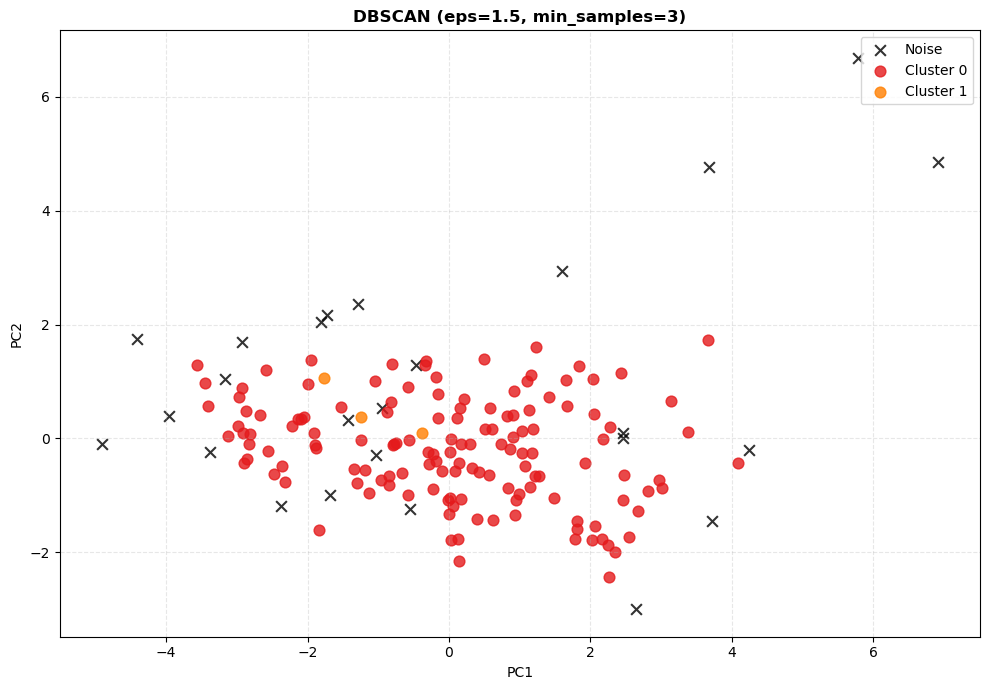

In [165]:
# Visualise DBSCAN clusters
unique_labels = sorted(set(dbscan_labels))
cmap_db = plt.cm.get_cmap("Set1", n_db_clusters + 1)

fig, ax = plt.subplots(figsize=(10, 7))
for lbl in unique_labels:
    mask   = dbscan_labels == lbl
    colour = "black" if lbl == -1 else cmap_db(lbl)
    marker = "x"     if lbl == -1 else "o"
    label  = "Noise" if lbl == -1 else f"Cluster {lbl}"
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colour], marker=marker, s=60, alpha=0.8, label=label)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"DBSCAN (eps={best_eps}, min_samples={best_ms})",
             fontsize=12, fontweight="bold")
ax.legend(loc="best"); ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("15_dbscan_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

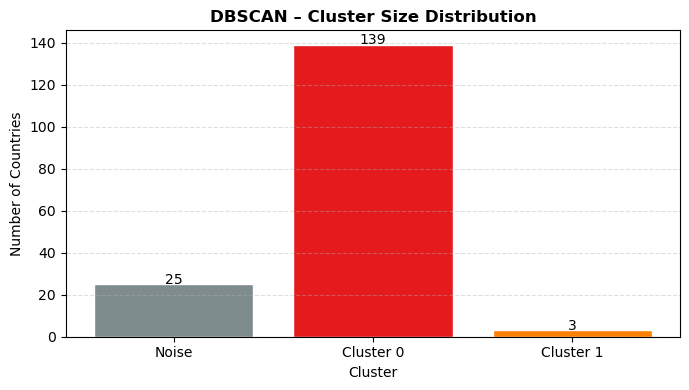

In [166]:
# Cluster size bar chart
dbscan_counts = pd.Series(dbscan_labels).value_counts().sort_index()
bar_labels = ["Noise" if i == -1 else f"Cluster {i}" for i in dbscan_counts.index]
bar_colors = ["#7f8c8d" if i == -1 else cmap_db(i)  for i in dbscan_counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bar_labels, dbscan_counts.values, color=bar_colors, edgecolor="white")
ax.set_title("DBSCAN – Cluster Size Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("Cluster"); ax.set_ylabel("Number of Countries")
ax.grid(axis="y", linestyle="--", alpha=0.4)
for i, v in enumerate(dbscan_counts.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("16_dbscan_cluster_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 7 – Clustering Comparison: K-Means vs. DBSCAN
Side-by-side PCA scatter and the **Adjusted Rand Index** to measure agreement between the two methods.

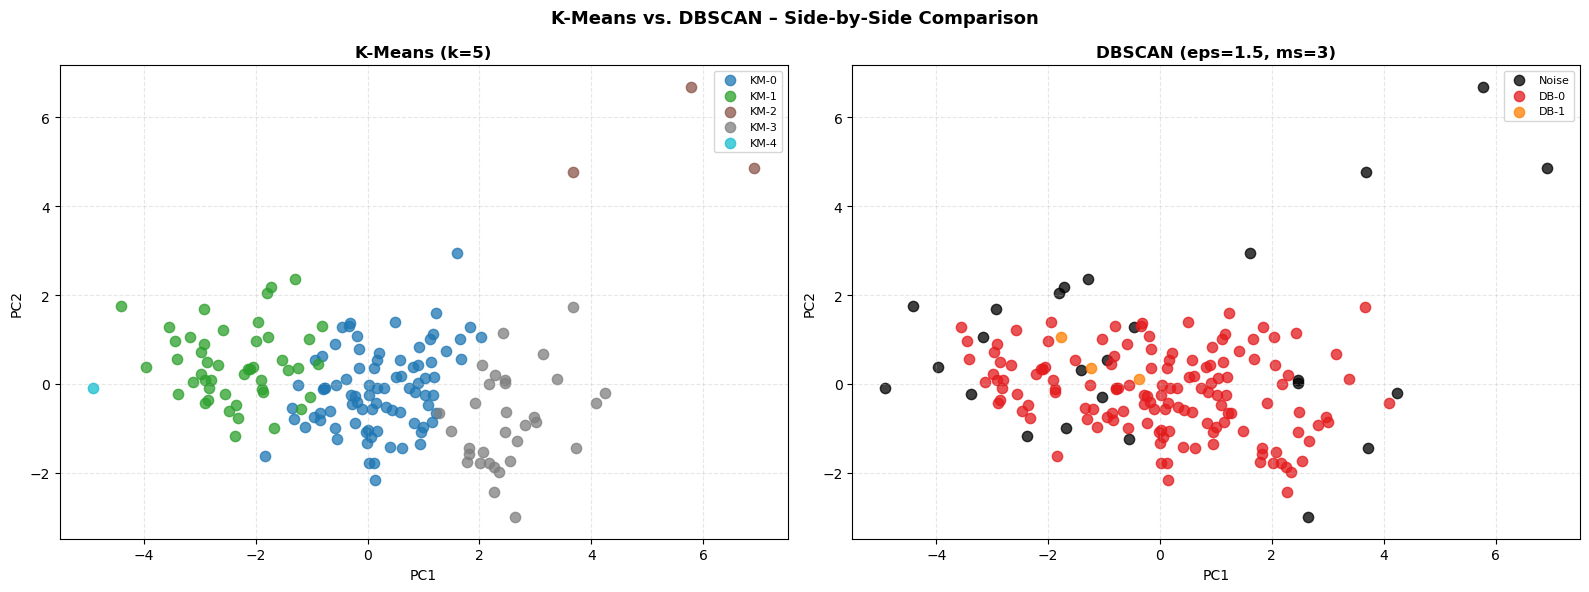

Adjusted Rand Index (K-Means vs DBSCAN): 0.1113


In [168]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for clust in range(best_k):
    mask = kmeans_labels == clust
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f"KM-{clust}", s=55, alpha=0.75,
                color=cmap_clusters(clust))
ax1.set_title(f"K-Means (k={best_k})", fontsize=12, fontweight="bold")
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2")
ax1.legend(fontsize=8); ax1.grid(linestyle="--", alpha=0.3)

for lbl in unique_labels:
    mask   = dbscan_labels == lbl
    colour = "black" if lbl == -1 else cmap_db(lbl)
    label  = "Noise" if lbl == -1 else f"DB-{lbl}"
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[colour], s=55, alpha=0.75, label=label)
ax2.set_title(f"DBSCAN (eps={best_eps}, ms={best_ms})",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
ax2.legend(fontsize=8); ax2.grid(linestyle="--", alpha=0.3)

plt.suptitle("K-Means vs. DBSCAN – Side-by-Side Comparison",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("17_clustering_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

ari_val = adjusted_rand_score(kmeans_labels, dbscan_labels)
print(f"Adjusted Rand Index (K-Means vs DBSCAN): {ari_val:.4f}")

## Section 8 – Prepare Data for Supervised Classification
Encoding the development status label, combining scaled features + PCA scores, and doing a stratified train/test split.

In [170]:
le        = LabelEncoder()
y_encoded = le.fit_transform(df_raw["dev_status"])
class_names = le.classes_

# Combine original scaled features + PCA scores
X_clf = np.hstack([X_scaled, X_pca])

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Train : {X_train.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")
print(f"Classes: {list(class_names)}")

Train : 133 samples
Test  : 34 samples
Classes: ['Developed', 'Developing', 'Underdeveloped']


## Section 9 – Baseline Classifiers
Comparing four baseline models — Decision Tree, KNN, Logistic Regression, and SVM — using 5-fold cross-validation.

In [172]:
baseline_models = {
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF)"          : SVC(kernel="rbf", probability=True, random_state=42),
}

baseline_results = {}
for model_name, model in baseline_models.items():
    cv_scores = cross_val_score(model, X_clf, y_encoded, cv=5, scoring="accuracy")
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    baseline_results[model_name] = {
        "CV Mean" : round(cv_scores.mean(), 4),
        "CV Std"  : round(cv_scores.std(),  4),
        "Test Acc": round(test_acc, 4)
    }
    print(f"{model_name:25s} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test: {test_acc:.4f}")

baseline_df = pd.DataFrame(baseline_results).T
print("\n── Baseline Model Summary ──")
baseline_df

Decision Tree             | CV: 0.9701 ± 0.0192 | Test: 0.9412
K-Nearest Neighbors       | CV: 0.8317 ± 0.0540 | Test: 0.7941
Logistic Regression       | CV: 0.8556 ± 0.0626 | Test: 0.9118
SVM (RBF)                 | CV: 0.8558 ± 0.0456 | Test: 0.9118

── Baseline Model Summary ──


,CV Mean,CV Std,Test Acc
Decision Tree,0.9701,0.0192,0.9412
K-Nearest Neighbors,0.8317,0.0540,0.7941
Logistic Regression,0.8556,0.0626,0.9118
SVM (RBF),0.8558,0.0456,0.9118


## Section 10 – Random Forest (Ensemble)
GridSearchCV hyperparameter tuning, OOB error analysis, confusion matrix and feature importance for the Random Forest classifier.

In [174]:
rf_param_grid = {
    "n_estimators"     : [100, 200],
    "max_depth"        : [None, 5, 10],
    "min_samples_split": [2, 5],
    "max_features"     : ["sqrt", "log2"]
}
rf_base = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=5,
                       scoring="accuracy", n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

print(f"Best RF params  : {rf_grid.best_params_}")
print(f"Best CV Accuracy: {rf_grid.best_score_:.4f}")

rf_preds = best_rf.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)
print(f"Test Accuracy   : {rf_acc:.4f}")

Best RF params  : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best CV Accuracy: 0.9467
Test Accuracy   : 0.9412


In [175]:
print("── Random Forest Classification Report ──")
print(classification_report(y_test, rf_preds, target_names=class_names))

── Random Forest Classification Report ──
                precision    recall  f1-score   support

     Developed       0.89      1.00      0.94         8
    Developing       1.00      0.83      0.91        12
Underdeveloped       0.93      1.00      0.97        14

      accuracy                           0.94        34
     macro avg       0.94      0.94      0.94        34
  weighted avg       0.95      0.94      0.94        34



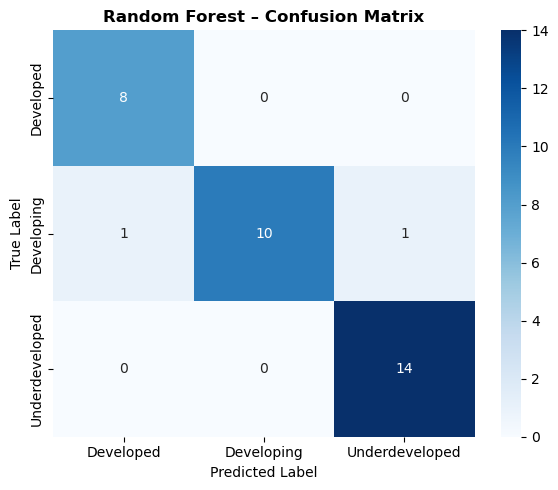

In [176]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Random Forest – Confusion Matrix", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig("18_rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

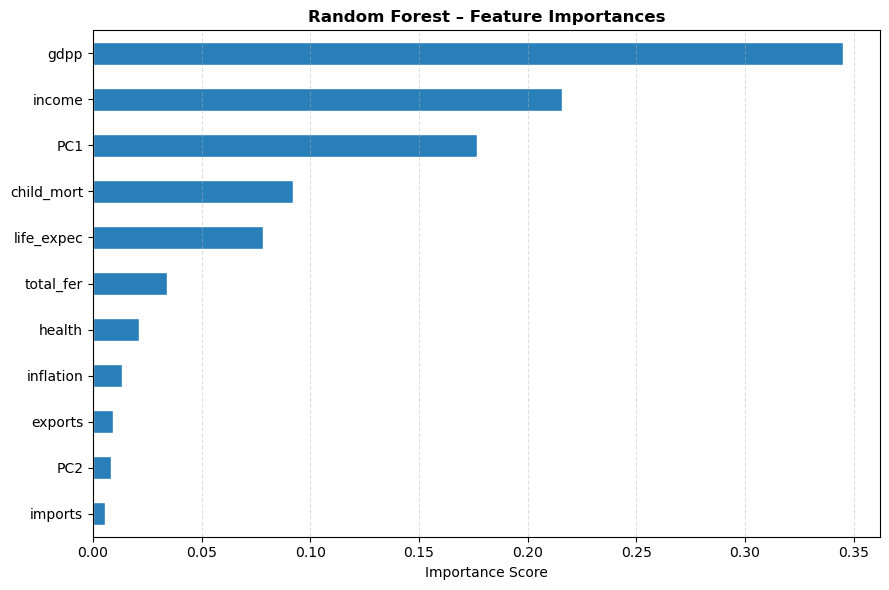

In [177]:
# Feature Importance
feature_names = numeric_cols + ["PC1", "PC2"]
fi_rf = pd.Series(best_rf.feature_importances_,
                  index=feature_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
fi_rf.plot(kind="barh", color="#2980b9", ax=ax, edgecolor="white")
ax.set_title("Random Forest – Feature Importances",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("19_rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

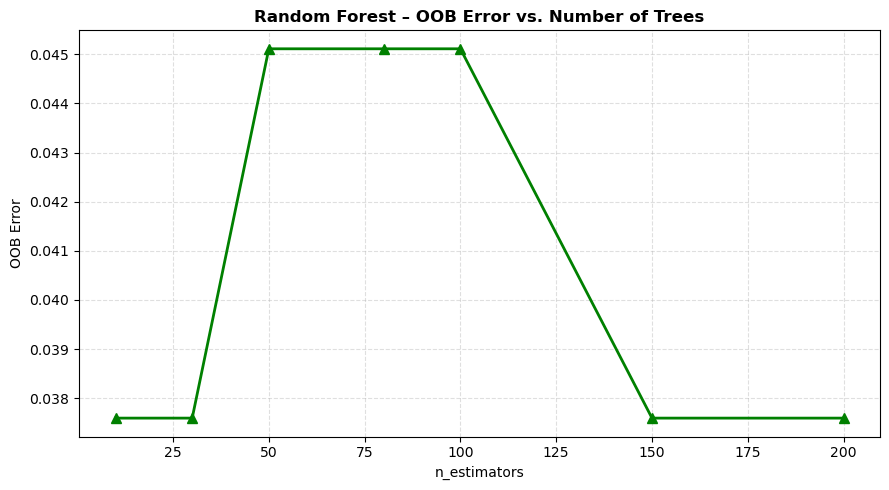

In [178]:
# OOB Error vs. Number of Trees
oob_errors = []
estimator_range = [10, 30, 50, 80, 100, 150, 200]
for n in estimator_range:
    rf_oob = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    rf_oob.fit(X_train, y_train)
    oob_errors.append(1 - rf_oob.oob_score_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(estimator_range, oob_errors, "g-^", linewidth=2, markersize=7)
ax.set_title("Random Forest – OOB Error vs. Number of Trees",
             fontsize=12, fontweight="bold")
ax.set_xlabel("n_estimators"); ax.set_ylabel("OOB Error")
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("20_rf_oob_error.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 11 – XGBoost (Ensemble)
GridSearchCV tuning for XGBoost, followed by a training vs. validation log-loss learning curve and feature importance chart.

In [180]:
xgb_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth"    : [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample"    : [0.8, 1.0]
}
xgb_base = xgb.XGBClassifier(use_label_encoder=False,
                               eval_metric="mlogloss", random_state=42)
xgb_grid = GridSearchCV(xgb_base, xgb_param_grid, cv=5,
                         scoring="accuracy", n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

print(f"Best XGB params  : {xgb_grid.best_params_}")
print(f"Best CV Accuracy : {xgb_grid.best_score_:.4f}")

xgb_preds = best_xgb.predict(X_test)
xgb_acc   = accuracy_score(y_test, xgb_preds)
print(f"Test Accuracy    : {xgb_acc:.4f}")

Best XGB params  : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV Accuracy : 0.9538
Test Accuracy    : 0.9412


In [181]:
print("── XGBoost Classification Report ──")
print(classification_report(y_test, xgb_preds, target_names=class_names))

── XGBoost Classification Report ──
                precision    recall  f1-score   support

     Developed       0.89      1.00      0.94         8
    Developing       1.00      0.83      0.91        12
Underdeveloped       0.93      1.00      0.97        14

      accuracy                           0.94        34
     macro avg       0.94      0.94      0.94        34
  weighted avg       0.95      0.94      0.94        34



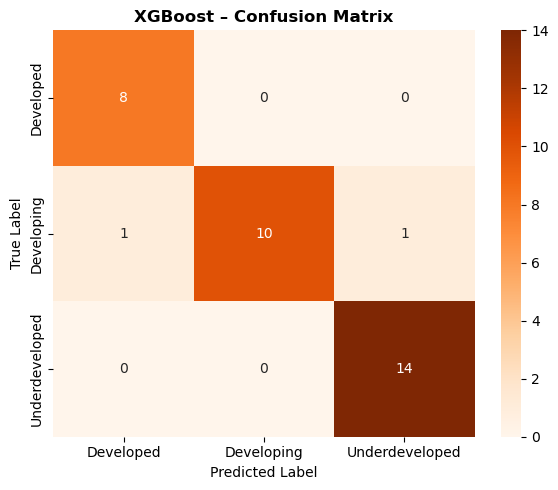

In [182]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_xgb = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("XGBoost – Confusion Matrix", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig("21_xgb_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

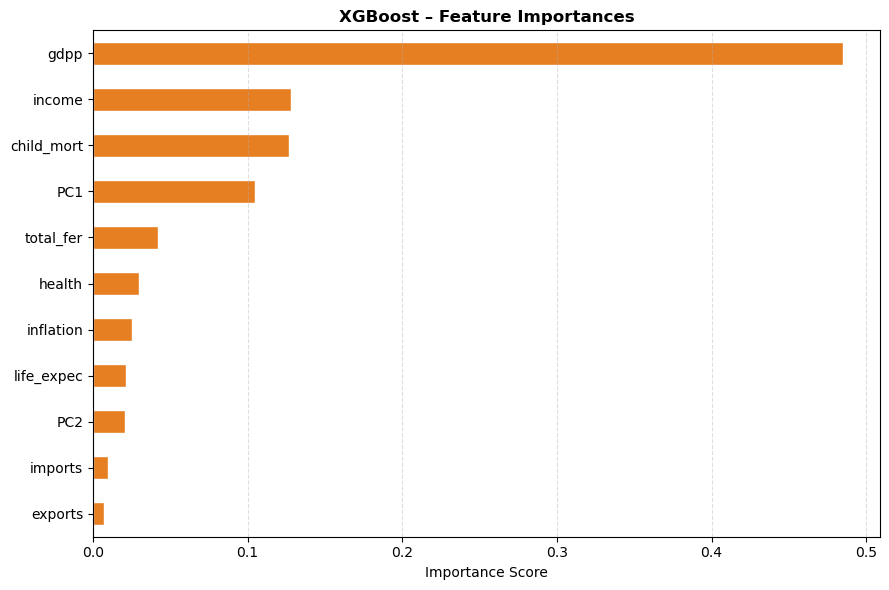

In [183]:
# Feature Importance
fi_xgb = pd.Series(best_xgb.feature_importances_,
                   index=feature_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
fi_xgb.plot(kind="barh", color="#e67e22", ax=ax, edgecolor="white")
ax.set_title("XGBoost – Feature Importances",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("22_xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

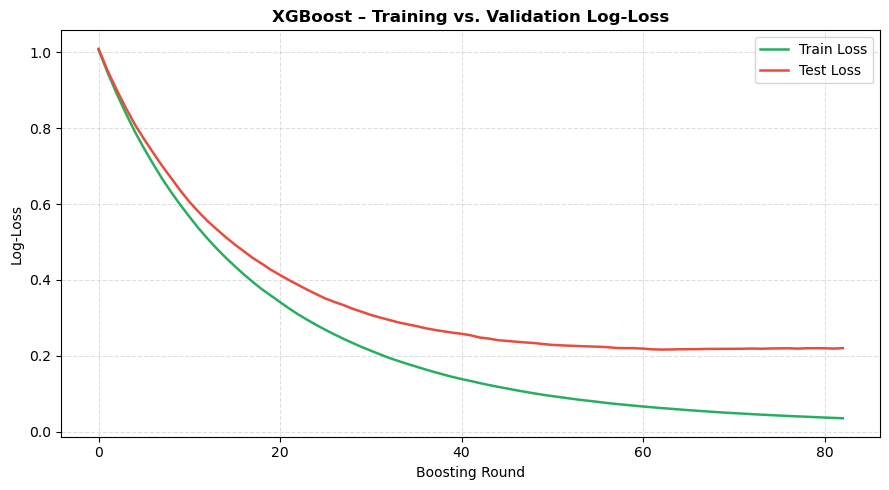

In [184]:
# Training vs. Validation Log-Loss Learning Curve
xgb_eval = xgb.XGBClassifier(
    n_estimators=200,
    max_depth      = best_xgb.max_depth,
    learning_rate  = best_xgb.learning_rate,
    subsample      = best_xgb.subsample,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    early_stopping_rounds=20
)
xgb_eval.fit(X_train, y_train,
             eval_set=[(X_train, y_train), (X_test, y_test)],
             verbose=False)
results = xgb_eval.evals_result()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results["validation_0"]["mlogloss"], label="Train Loss",
        color="#27ae60", linewidth=1.8)
ax.plot(results["validation_1"]["mlogloss"], label="Test Loss",
        color="#e74c3c", linewidth=1.8)
ax.set_title("XGBoost – Training vs. Validation Log-Loss",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Boosting Round"); ax.set_ylabel("Log-Loss")
ax.legend(); ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("23_xgb_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 12 – Gradient Boosting (Additional Ensemble)
Adding sklearn's `GradientBoostingClassifier` as a third ensemble method for a more complete comparison.

In [186]:
gb_model = GradientBoostingClassifier(
    n_estimators=150, max_depth=4,
    learning_rate=0.1, subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_acc   = accuracy_score(y_test, gb_preds)
gb_cv    = cross_val_score(gb_model, X_clf, y_encoded, cv=5).mean()

print(f"Gradient Boosting CV Accuracy   : {gb_cv:.4f}")
print(f"Gradient Boosting Test Accuracy : {gb_acc:.4f}")

Gradient Boosting CV Accuracy   : 0.9522
Gradient Boosting Test Accuracy : 0.9412


## Section 13 – Model Performance Comparison
Final leaderboard: all classifiers ranked by test accuracy with a grouped bar chart.

In [188]:
all_models_results = {
    **{m: {"Test Accuracy": baseline_results[m]["Test Acc"],
           "CV Accuracy"  : baseline_results[m]["CV Mean"]}
       for m in baseline_results},
    "Random Forest (tuned)": {"Test Accuracy": rf_acc,
                               "CV Accuracy"  : rf_grid.best_score_},
    "XGBoost (tuned)"      : {"Test Accuracy": xgb_acc,
                               "CV Accuracy"  : xgb_grid.best_score_},
    "Gradient Boosting"    : {"Test Accuracy": gb_acc,
                               "CV Accuracy"  : gb_cv},
}
comparison_df = pd.DataFrame(all_models_results).T.sort_values(
    "Test Accuracy", ascending=False)
comparison_df.round(4)

,Test Accuracy,CV Accuracy
Decision Tree,0.9412,0.9701
Random Forest (tuned),0.9412,0.9467
XGBoost (tuned),0.9412,0.9538
Gradient Boosting,0.9412,0.9522
Logistic Regression,0.9118,0.8556
SVM (RBF),0.9118,0.8558
K-Nearest Neighbors,0.7941,0.8317


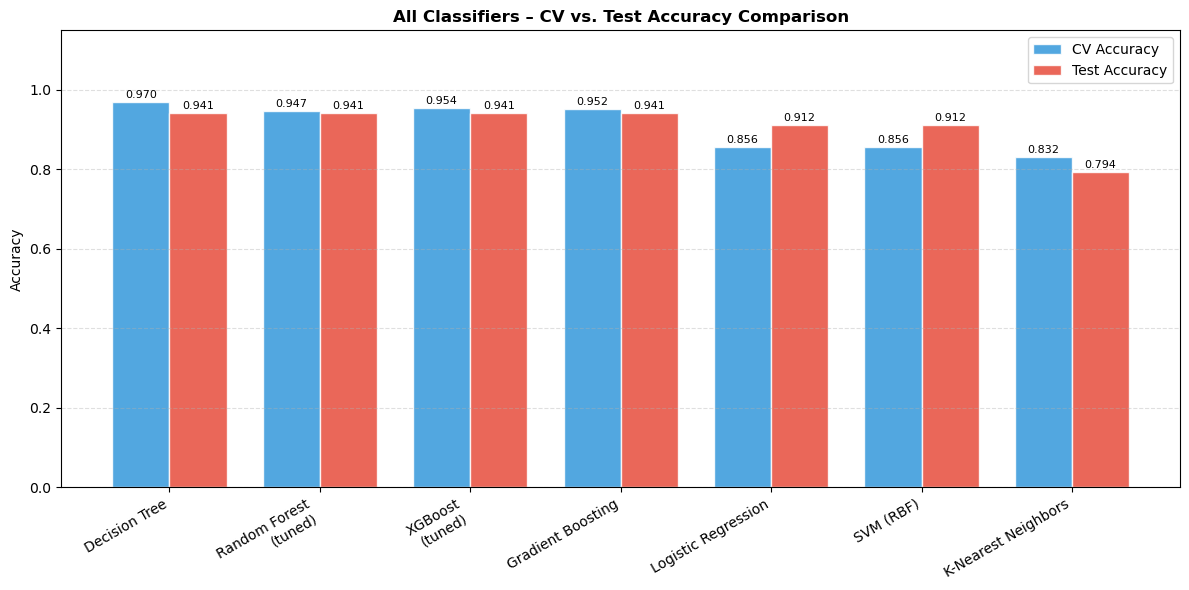

In [189]:
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(comparison_df))
width = 0.38
ax.bar(x_pos - width/2, comparison_df["CV Accuracy"],
       width, label="CV Accuracy",   color="#3498db", alpha=0.85, edgecolor="white")
ax.bar(x_pos + width/2, comparison_df["Test Accuracy"],
       width, label="Test Accuracy", color="#e74c3c", alpha=0.85, edgecolor="white")
ax.set_xticks(x_pos)
ax.set_xticklabels([m.replace(" (tuned)", "\n(tuned)")
                    for m in comparison_df.index],
                   rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Accuracy")
ax.set_title("All Classifiers – CV vs. Test Accuracy Comparison",
             fontsize=12, fontweight="bold")
ax.legend(); ax.set_ylim(0, 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.4)
for i, (cv_v, test_v) in enumerate(zip(comparison_df["CV Accuracy"],
                                        comparison_df["Test Accuracy"])):
    ax.text(i - width/2, cv_v + 0.01,   f"{cv_v:.3f}",   ha="center", fontsize=8)
    ax.text(i + width/2, test_v + 0.01, f"{test_v:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("24_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 14 – Cluster-Based Insight Analysis
Cross-tabulation of clusters vs. development status, GDP / child mortality profiles, and a radar chart of normalised cluster features.

In [191]:
# Cross-tab: K-Means cluster × development status
cross_tab = pd.crosstab(df_raw["kmeans_cluster"],
                        df_raw["dev_status"], margins=True)
print("── K-Means Cluster × Development Status ──")
cross_tab

── K-Means Cluster × Development Status ──


dev_status,Developed,Developing,Underdeveloped,All
kmeans_cluster,,,,
0,5,55,24,84
1,0,4,43,47
2,3,0,0,3
3,31,1,0,32
4,0,0,1,1
All,39,60,68,167


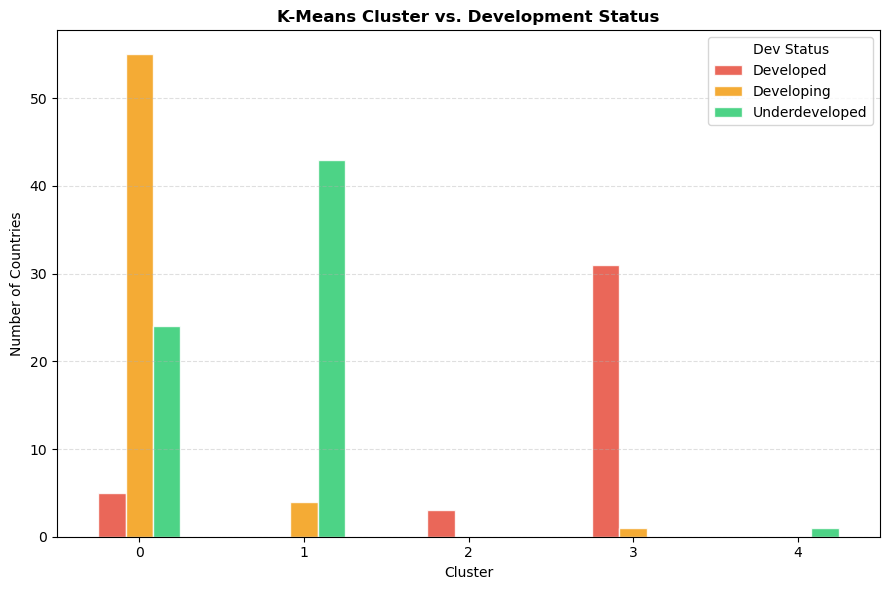

In [192]:
fig, ax = plt.subplots(figsize=(9, 6))
cross_tab.drop("All", axis=0).drop("All", axis=1).plot(
    kind="bar", ax=ax, color=["#e74c3c", "#f39c12", "#2ecc71"],
    edgecolor="white", alpha=0.85)
ax.set_title("K-Means Cluster vs. Development Status",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Cluster"); ax.set_ylabel("Number of Countries")
ax.legend(title="Dev Status"); ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("25_cluster_vs_devstatus.png", dpi=150, bbox_inches="tight")
plt.show()

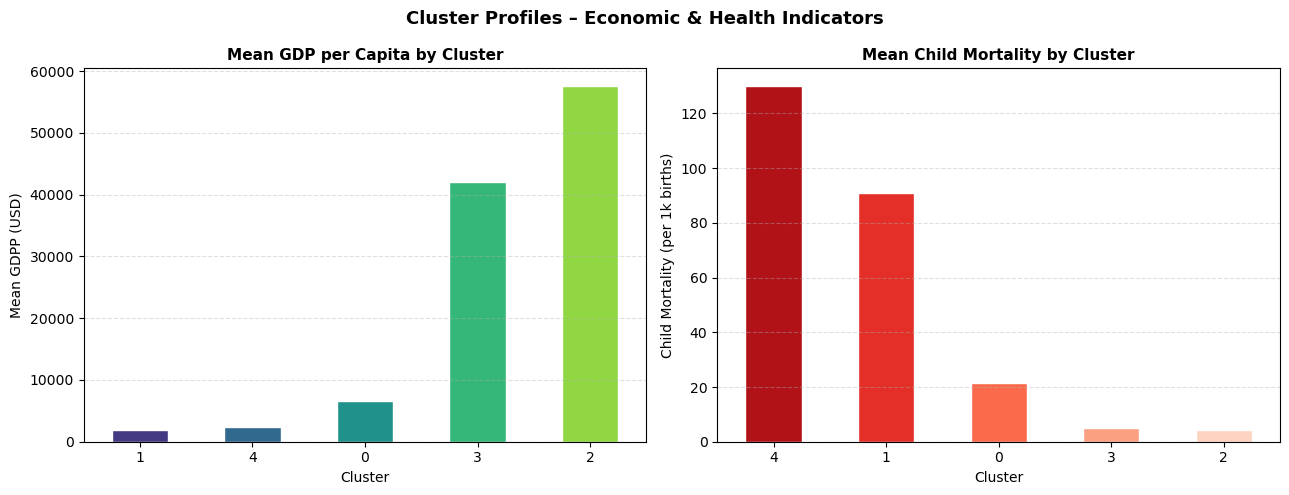

In [193]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

gdpp_per_cluster = df_raw.groupby("kmeans_cluster")["gdpp"].mean().sort_values()
gdpp_per_cluster.plot(kind="bar", ax=ax1,
                      color=sns.color_palette("viridis", len(gdpp_per_cluster)),
                      edgecolor="white")
ax1.set_title("Mean GDP per Capita by Cluster", fontsize=11, fontweight="bold")
ax1.set_xlabel("Cluster"); ax1.set_ylabel("Mean GDPP (USD)")
ax1.tick_params(axis="x", rotation=0); ax1.grid(axis="y", linestyle="--", alpha=0.4)

mort_per_cluster = df_raw.groupby("kmeans_cluster")["child_mort"].mean().sort_values(ascending=False)
mort_per_cluster.plot(kind="bar", ax=ax2,
                      color=sns.color_palette("Reds_r", len(mort_per_cluster)),
                      edgecolor="white")
ax2.set_title("Mean Child Mortality by Cluster", fontsize=11, fontweight="bold")
ax2.set_xlabel("Cluster"); ax2.set_ylabel("Child Mortality (per 1k births)")
ax2.tick_params(axis="x", rotation=0); ax2.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Cluster Profiles – Economic & Health Indicators",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("26_cluster_insight_gdp_mort.png", dpi=150, bbox_inches="tight")
plt.show()

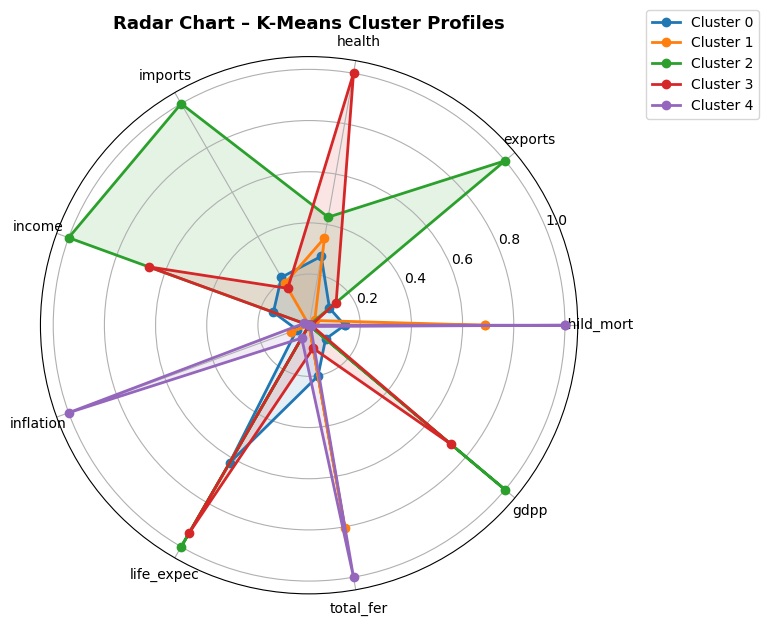

In [194]:
# Radar chart for cluster profiles
norm_profiles = (cluster_profiles - cluster_profiles.min()) / (
    cluster_profiles.max() - cluster_profiles.min() + 1e-9)

categories = list(norm_profiles.columns)
N      = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
palette = sns.color_palette("tab10", len(norm_profiles))

for i, (clust_id, row) in enumerate(norm_profiles.iterrows()):
    vals = list(row.values) + [row.values[0]]
    ax.plot(angles, vals, "o-", linewidth=2,
            color=palette[i], label=f"Cluster {clust_id}")
    ax.fill(angles, vals, alpha=0.12, color=palette[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_title("Radar Chart – K-Means Cluster Profiles",
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig("27_cluster_radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 15 – Final Summary Dashboard
A single multi-panel figure combining cluster sizes, model leaderboard, PCA scatter (both algorithms), top RF features, and the correlation matrix.

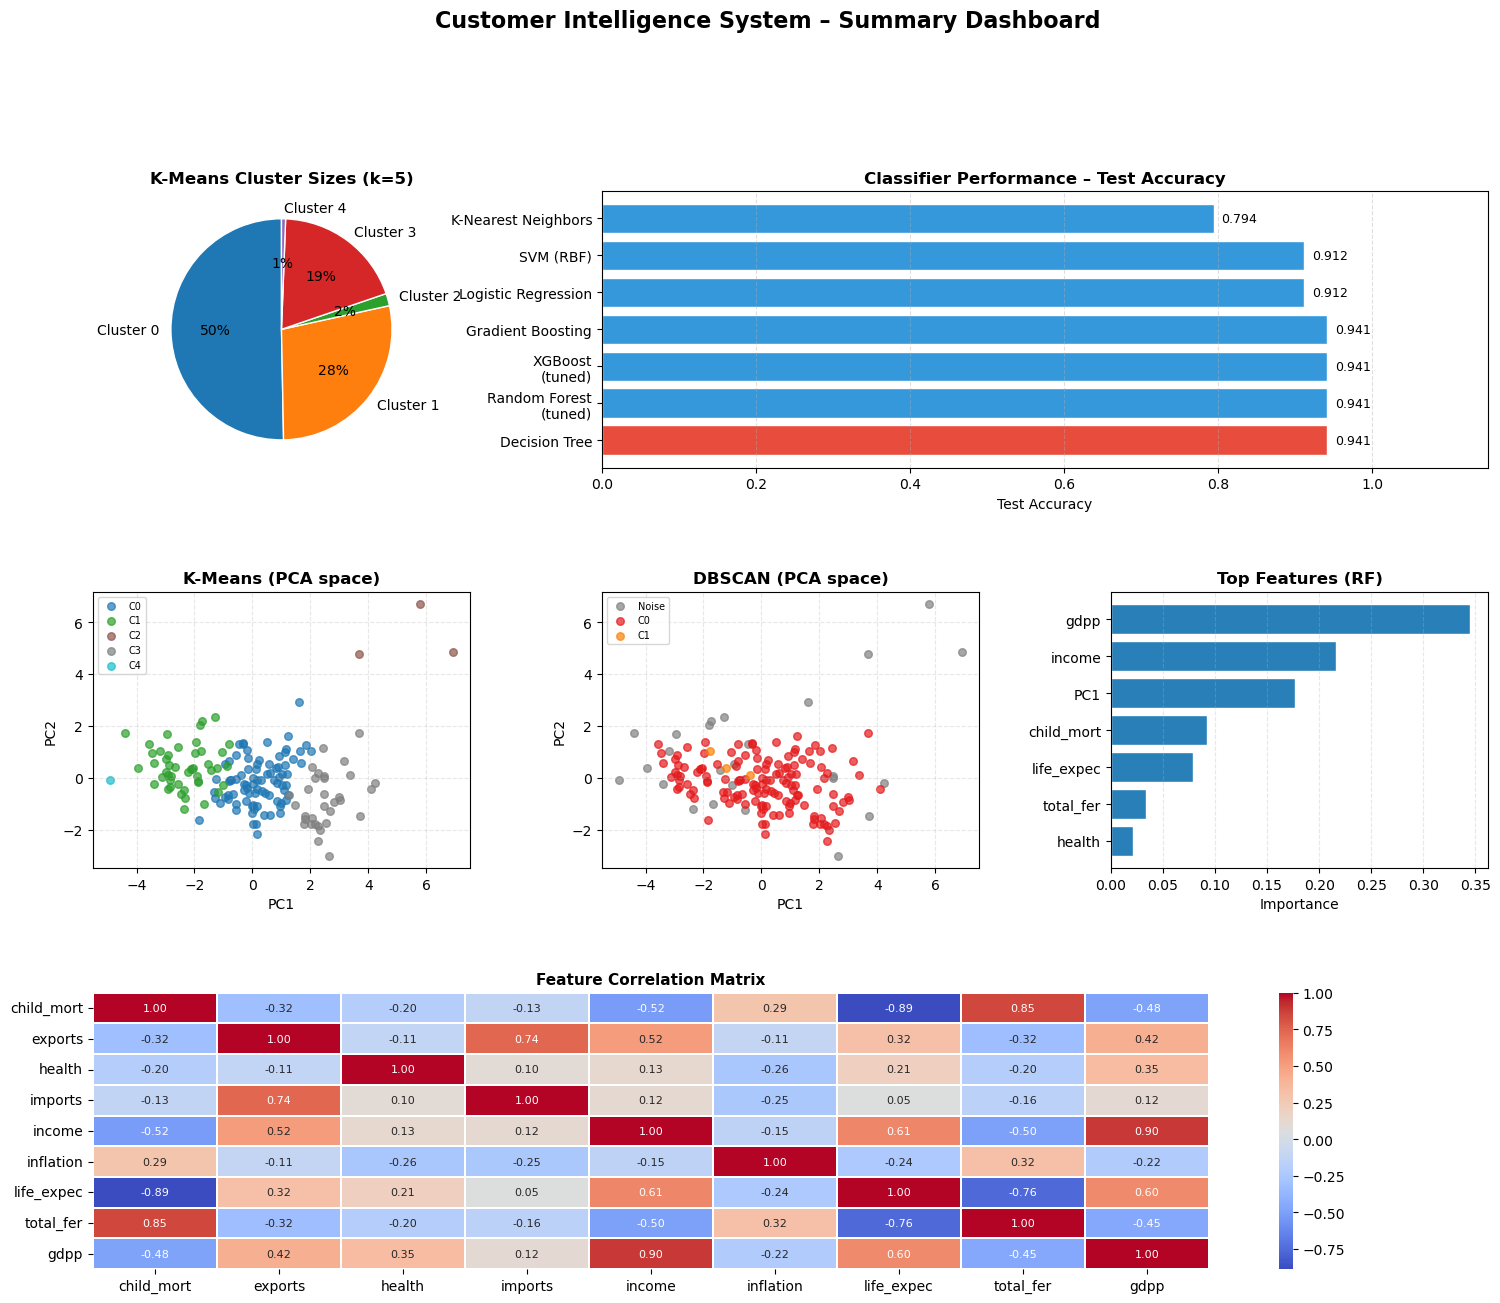

In [196]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1 – Cluster sizes (pie)
ax_a = fig.add_subplot(gs[0, 0])
km_sizes = df_raw["kmeans_cluster"].value_counts().sort_index()
ax_a.pie(km_sizes.values,
         labels=[f"Cluster {c}" for c in km_sizes.index],
         autopct="%1.0f%%", colors=sns.color_palette("tab10", best_k),
         startangle=90, wedgeprops={"edgecolor": "white"})
ax_a.set_title(f"K-Means Cluster Sizes (k={best_k})", fontweight="bold")

# Panel 2 – Model accuracy (bar)
ax_b = fig.add_subplot(gs[0, 1:])
test_acc_vals = comparison_df["Test Accuracy"].values
model_labels  = [m.replace(" (tuned)", "\n(tuned)") for m in comparison_df.index]
bar_cols = ["#e74c3c" if v == max(test_acc_vals) else "#3498db" for v in test_acc_vals]
ax_b.barh(model_labels, test_acc_vals, color=bar_cols, edgecolor="white")
ax_b.set_xlabel("Test Accuracy")
ax_b.set_title("Classifier Performance – Test Accuracy", fontweight="bold")
ax_b.set_xlim(0, 1.15); ax_b.grid(axis="x", linestyle="--", alpha=0.4)
for i, v in enumerate(test_acc_vals):
    ax_b.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

# Panel 3 – K-Means PCA scatter
ax_c = fig.add_subplot(gs[1, 0])
for clust in range(best_k):
    mask = kmeans_labels == clust
    ax_c.scatter(X_pca[mask,0], X_pca[mask,1], s=30, alpha=0.7,
                 color=cmap_clusters(clust), label=f"C{clust}")
ax_c.set_title("K-Means (PCA space)", fontweight="bold")
ax_c.set_xlabel("PC1"); ax_c.set_ylabel("PC2")
ax_c.legend(fontsize=7); ax_c.grid(linestyle="--", alpha=0.3)

# Panel 4 – DBSCAN PCA scatter
ax_d = fig.add_subplot(gs[1, 1])
for lbl in unique_labels:
    mask   = dbscan_labels == lbl
    colour = "grey" if lbl == -1 else cmap_db(lbl)
    ax_d.scatter(X_pca[mask,0], X_pca[mask,1], c=[colour], s=30,
                 alpha=0.7, label="Noise" if lbl == -1 else f"C{lbl}")
ax_d.set_title("DBSCAN (PCA space)", fontweight="bold")
ax_d.set_xlabel("PC1"); ax_d.set_ylabel("PC2")
ax_d.legend(fontsize=7); ax_d.grid(linestyle="--", alpha=0.3)

# Panel 5 – Top RF Features
ax_e = fig.add_subplot(gs[1, 2])
fi_sorted = fi_rf.tail(7)
ax_e.barh(fi_sorted.index, fi_sorted.values, color="#2980b9", edgecolor="white")
ax_e.set_title("Top Features (RF)", fontweight="bold")
ax_e.set_xlabel("Importance"); ax_e.grid(axis="x", linestyle="--", alpha=0.3)

# Panel 6 – Correlation heatmap
ax_f = fig.add_subplot(gs[2, :])
sns.heatmap(df_raw[numeric_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.3, ax=ax_f, annot_kws={"size": 8})
ax_f.set_title("Feature Correlation Matrix", fontweight="bold", fontsize=11)

plt.suptitle("Customer Intelligence System – Summary Dashboard",
             fontsize=16, fontweight="bold", y=1.01)
plt.savefig("28_final_summary_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 16 – Final Metrics Summary & Conclusion
Clustering evaluation table, final model leaderboard, and the winning classifier.

In [198]:
# Clustering metrics table
cluster_metrics = {
    "Algorithm"       : ["K-Means", "DBSCAN"],
    "# Clusters"      : [best_k, n_db_clusters],
    "# Noise Points"  : [0, int((dbscan_labels == -1).sum())],
    "Silhouette Score": [round(silhouette_score(X_scaled, kmeans_labels), 4),
                         round(best_dbscan["silhouette"], 4)],
    "Davies-Bouldin"  : [round(davies_bouldin_score(X_scaled, kmeans_labels), 4), "N/A"]
}
cm_df = pd.DataFrame(cluster_metrics).set_index("Algorithm")
print("── Clustering Evaluation Metrics ──")
display(cm_df)

── Clustering Evaluation Metrics ──


,# Clusters,# Noise Points,Silhouette Score,Davies-Bouldin
Algorithm,,,,
K-Means,5,0,0.2993,0.8718
DBSCAN,2,25,0.1540,N/A


In [199]:
# Final supervised model leaderboard
print("── Supervised Model Final Leaderboard ──")
display(comparison_df.round(4))

best_model_name = comparison_df["Test Accuracy"].idxmax()
best_model_acc  = comparison_df["Test Accuracy"].max()
print(f"\n🏆  Best Classifier : {best_model_name}")
print(f"    Test Accuracy    : {best_model_acc:.4f}")

print("\n" + "=" * 65)
print("  ALL TASKS COMPLETED SUCCESSFULLY!")
print("  28 plots have been saved to the working directory.")
print("=" * 65)

── Supervised Model Final Leaderboard ──


,Test Accuracy,CV Accuracy
Decision Tree,0.9412,0.9701
Random Forest (tuned),0.9412,0.9467
XGBoost (tuned),0.9412,0.9538
Gradient Boosting,0.9412,0.9522
Logistic Regression,0.9118,0.8556
SVM (RBF),0.9118,0.8558
K-Nearest Neighbors,0.7941,0.8317



🏆  Best Classifier : Decision Tree
    Test Accuracy    : 0.9412

  ALL TASKS COMPLETED SUCCESSFULLY!
  28 plots have been saved to the working directory.
